## Importing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Setting a consistent tone for our visualisation

In [ ]:
#--- Set a consistent dark-theme style for all charts ---
# These settings apply globally to every chart created after this point
plt.rcParams.update({
    'figure.facecolor': '#0f0f14',   # dark background for the whole figure
    'axes.facecolor':   '#0f0f14',   # dark background inside the chart area
    'axes.edgecolor':   '#2a2a3a',   # subtle border around the chart
    'axes.labelcolor':  '#c8c4b8',   # axis label text colour
    'text.color':       '#c8c4b8',   # general text colour
    'xtick.color':      '#666680',   # x-axis tick marks
    'ytick.color':      '#666680',   # y-axis tick marks
    'grid.color':       '#1e1e2e',   # light grid lines
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#e0dcd4',
    'figure.titlesize': 15,
})

# A shared colour palette — we use the same colours throughout all charts
# so the notebook looks consistent and professional
ACCENT = ['#d4e832', '#e8622a', '#18c9a0', '#a66ef5', '#3ba9e8', '#f5a623', '#e84393']


## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_path = '/content/drive/MyDrive/Sales Retail Dataset/retail_sales_cleaned.csv'
df = pd.read_csv(drive_path)
display(df.head())

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,3903,2024-08-15,32603,Aarav Mehta,39,3,C,Raipur,Groceries,Sugar,...,346.32,0.00,4043.14,289.18,56.04,Debit Card,3,1,Returned,7
1,2198,2022-08-16,7881,Sanjay Verma,28,1,W,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5,0,Delivered,2
2,1348,2021-08-29,49296,Pooja Sharma,41,3,W,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4,0,Delivered,5
3,2076,2022-07-05,5587,Priya Reddy,29,3,W,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,Emi,3,0,Delivered,4
4,287,2020-05-07,58035,Ritu Sharma,9,1,C,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4,0,Pending,4


In [ ]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='object')

## Checking for the percentages of Repeat customers

In [ ]:
repeat_customers = df.groupby('customer_id').filter(lambda x: len(x) > 1)
num_repeat_customers = repeat_customers['customer_id'].nunique()

print(f'Number of repeat customers: {num_repeat_customers}')
# Display some repeat customer details if needed
# print(repeat_customers['customer_id'].value_counts().head())

Number of repeat customers: 87


In [ ]:
total_unique_customers = df['customer_id'].nunique()

print(f'Total number of unique customers: {total_unique_customers}')

Total number of unique customers: 4112


In [ ]:
percentage_repeat_customers = (num_repeat_customers / total_unique_customers) * 100

print(f'Percentage of repeat customers: {percentage_repeat_customers:.2f}%')

Percentage of repeat customers: 2.12%


The data shows roughly 97.88% of customers placed only one order. This is common in e-commerce — first-time buyers who do not return. RFM helps with identifying the 2.12% who came back, understand what made them loyal, and build strategies to convert more first-timers into repeat buyers.

Step 1: Calculating recency, frequency and monetary

In [ ]:
# snapshot_date = one day after the last order in the dataset.
# This is our "today" — we measure recency relative to this date.

# Convert 'order_date' to datetime objects if not already done
df['order_date'] = pd.to_datetime(df['order_date'])

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = (
    df[df['order_status'] == 'Delivered'] # Corrected column from 'order_date' to 'order_status'
    .groupby('customer_id')
    .agg(
        # Recency: how many days since their most recent purchase?
        recency=(
            'order_date',
            lambda x: (snapshot_date - x.max()).days
        ),
        # Frequency: how many distinct orders did they place?
        frequency=('order_id', 'nunique'),

        # Monetary: total amount spent across all their orders
        monetary=('sales_amount', 'sum') # Corrected column from 'sales' to 'sales_amount'
    )
    .reset_index()
)

print(f'Unique customers in RFM table: {len(rfm):,}')
print(rfm.describe().round(2))

Unique customers in RFM table: 2,695
       customer_id  recency  frequency     monetary
count      2695.00  2695.00    2695.00      2695.00
mean      50235.56   885.36       1.01     67594.39
std       28820.96   507.65       0.11    387053.76
min          13.00     2.00       1.00        39.45
25%       24839.50   483.00       1.00      2488.88
50%       50156.00   833.00       1.00      9797.68
75%       74910.00  1305.00       1.00     53130.62
max       99976.00  1826.00       2.00  17360314.17


Step 2: Applying the Elbow Method to Determine Optimal RFM Segments

Before applying the elbow method, we need to scale the RFM features to ensure each feature contributes equally to the distance calculation in clustering. Then, we will use K-Means clustering and the elbow method to find the optimal number of segments (clusters).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare the RFM data for clustering (excluding 'customer_id')
rfm_data = rfm[['recency', 'frequency', 'monetary']]

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Convert scaled data back to a DataFrame for easier inspection
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_data.columns, index=rfm_data.index)

# Display a sample of the scaled data
print("Scaled RFM data head:")
display(rfm_scaled_df.head())

Scaled RFM data head:


,recency,frequency,monetary
0,-1.704950,-0.116357,-0.174095
1,-0.382927,-0.116357,-0.171417
2,-1.273470,-0.116357,-0.173082
3,-0.849871,-0.116357,-0.160150
4,-0.934591,-0.116357,-0.043704


Step 3: Visualising the elbow to determine optimal number of clusters using plot

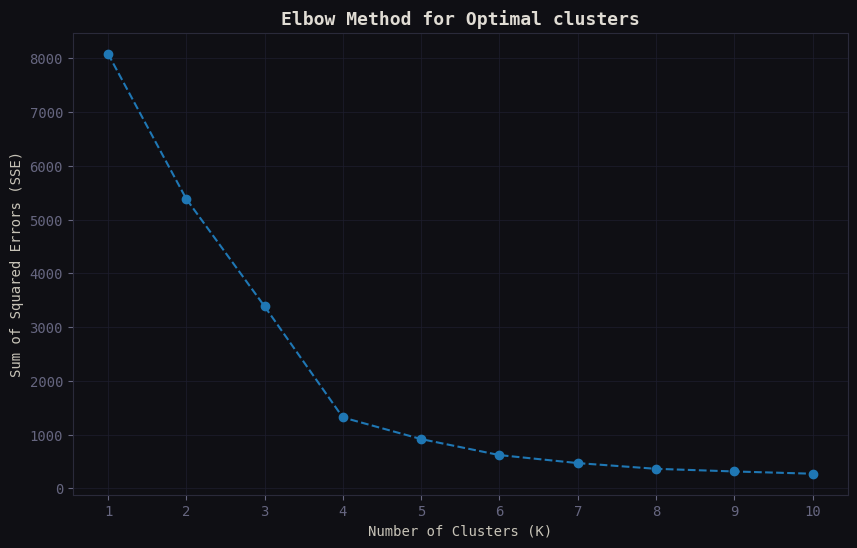

In [ ]:
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(rfm_scaled)
    sse[k] = kmeans.inertia_ # Inertia: Sum of squared distances of samples to their closest cluster center

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--')
plt.title('Elbow Method for Optimal clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.xticks(range(1, 11))
plt.show()


From the plot above the optimum number of clusters should be 4.

Step 4: Assign segments

In [ ]:
# RFM SCORING — Quintile-based (4 equal groups, scored 1 to 4)
# -------------------------------------------------------

# RECENCY: lower days = better customer → assign score 4 to lowest recency
# labels=[4,3,2,1] flips the scale: smallest recency bucket gets score 5
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)

# FREQUENCY: higher count = better → score 4 for highest frequency
# rank(method='first') breaks ties (many customers buy exactly once)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)

# MONETARY: higher spend = better → score 4 for top 20% of spenders
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

# Concatenate scores into a 3-digit string (e.g., "432" = R4, F3, M2)
# Useful for quick lookups, but we'll use the numeric scores for segmentation
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Apply business segment rules using a helper function
# Each row is a customer; we read their 3 scores and assign a segment label
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'          # recent + frequent + big spend
    if r >= 3 and f >= 3:            return 'Loyal'              # regular buyers
    if r >= 4 and f <= 2:            return 'New Customers'      # just arrived, low frequency so far
    if r <= 2 and f <= 2:            return 'Lost'               # both old and rare
    return 'Potential Loyalists'                                  # middle ground

rfm['segment'] = rfm.apply(segment, axis=1)

print('Customers per segment:')
print(rfm['segment'].value_counts())
print()
print('Average lifetime value (total spend) by segment:')
print(rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False).round(2))


Customers per segment:
segment
Potential Loyalists    1014
Lost                    678
Loyal                   628
New Customers           323
Champions                52
Name: count, dtype: int64

Average lifetime value (total spend) by segment:
segment
Champions              214303.21
Loyal                   83111.84
Lost                    73273.81
New Customers           52112.13
Potential Loyalists     51594.69
Name: monetary, dtype: float64


Step 5: Visualise RFM segments

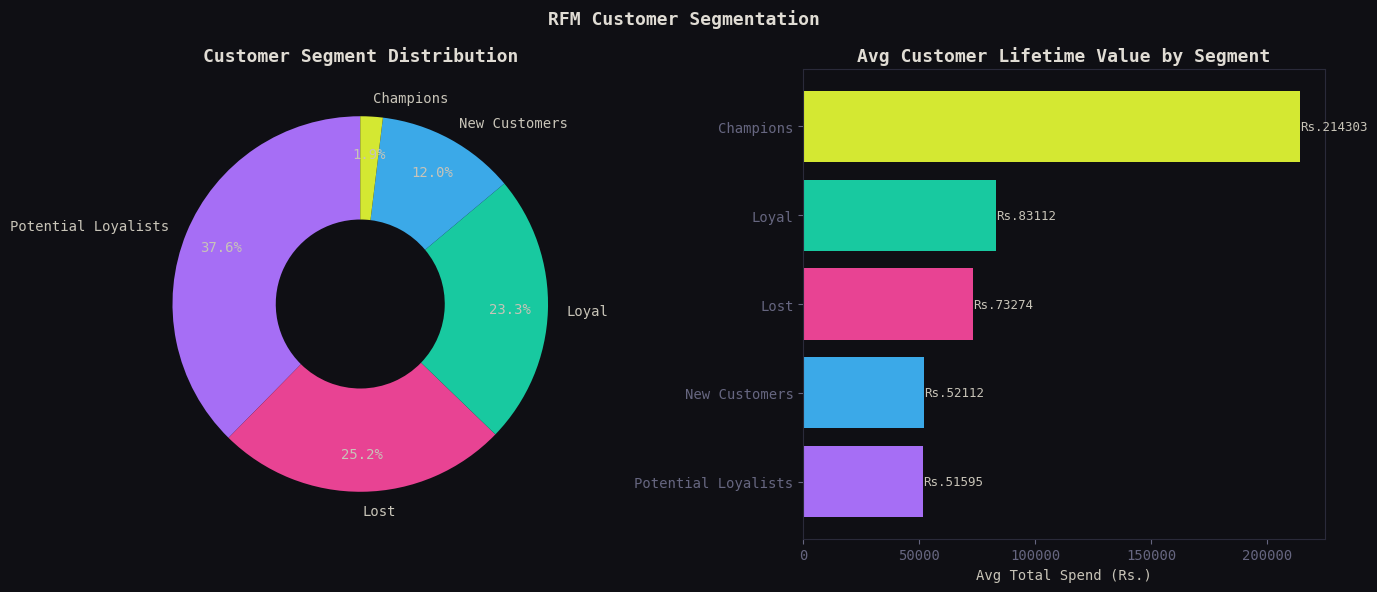

In [ ]:
seg_palette = {
    'Champions':'#d4e832','Loyal':'#18c9a0','New Customers':'#3ba9e8',
    'At Risk':'#e8622a','Lost':'#e84393','Potential Loyalists':'#a66ef5'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calculate segment counts
seg_counts = rfm['segment'].value_counts()

# Segment sizes donut
colors_seg = [seg_palette.get(s,'#555') for s in seg_counts.index]
axes[0].pie(seg_counts.values, labels=seg_counts.index, colors=colors_seg,
            autopct='%1.1f%%', startangle=90, pctdistance=0.8,
            wedgeprops={'width':0.55})
axes[0].set_title('Customer Segment Distribution')

# Avg monetary by segment (sorted)
seg_clv = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=True)
bar_colors = [seg_palette.get(s,'#555') for s in seg_clv.index]
axes[1].barh(seg_clv.index, seg_clv.values, color=bar_colors)
for i,v in enumerate(seg_clv.values):
    axes[1].text(v+5, i, f'Rs.{v:.0f}', va='center', fontsize=9)
axes[1].set_title('Avg Customer Lifetime Value by Segment')
axes[1].set_xlabel('Avg Total Spend (Rs.)')

plt.suptitle('RFM Customer Segmentation', fontsize=13, fontweight='bold', color='#e0dcd4')
plt.tight_layout(); plt.savefig('10_rfm.png', dpi=140, bbox_inches='tight'); plt.show()

Step 6: KMeans clustering on RFM(k=4)

         size  avg_recency  avg_frequency  avg_monetary
cluster                                                
0        1012       987.67            1.0     155979.89
1        1248      1042.66            1.0       3956.42
2          36       696.11            2.0     120494.17
3         399       150.90            1.0      37693.82


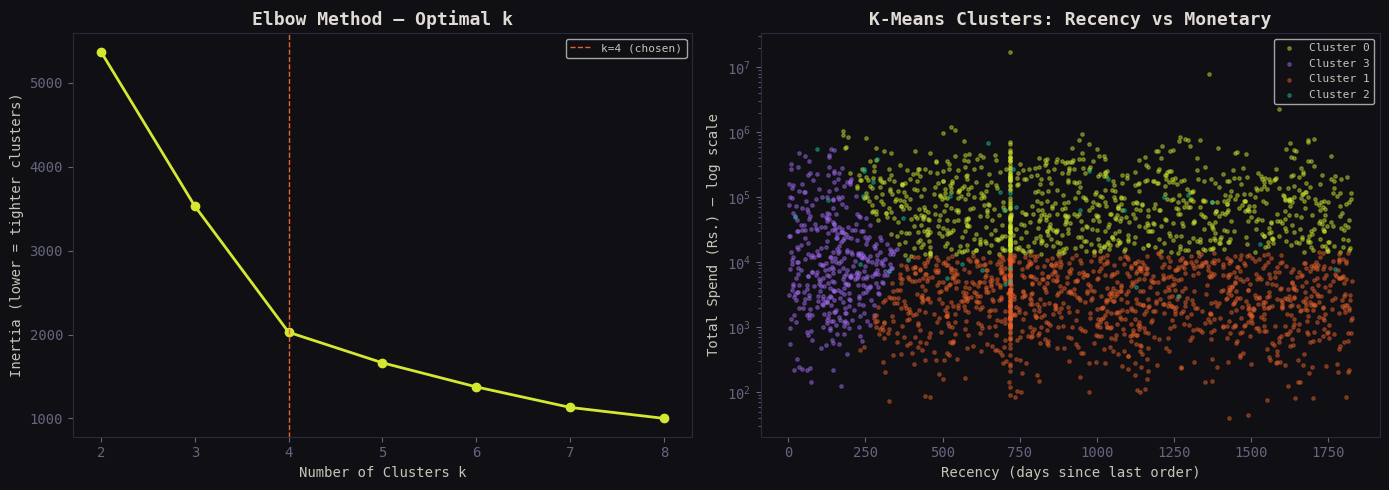

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# STEP 1: Prepare RFM features
# -------------------------------------------------------
# We use the raw recency/frequency/monetary values, NOT the quintile scores.
# Quintile scores lose information (many customers collapsed to the same score).
rfm_features = rfm[['recency', 'frequency', 'monetary']].copy()

# STEP 2: Log-transform to compress extreme ranges
# -------------------------------------------------------
# Without this: recency=600 days would dominate over frequency=3 in distance calculations
# np.log1p(x) = log(1 + x)  — the +1 handles zero values gracefully
rfm_features['recency']   = np.log1p(rfm_features['recency'])
rfm_features['frequency'] = np.log1p(rfm_features['frequency'])
rfm_features['monetary']  = np.log1p(rfm_features['monetary'])

# STEP 3: Scale to mean=0, std=1 so all 3 dimensions have equal influence
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# STEP 4: Elbow Method — find the best k
# -------------------------------------------------------
# Inertia = sum of squared distances from each point to its cluster centre
# Lower inertia = tighter, more compact clusters
# We look for the "elbow" where adding more clusters gives diminishing returns
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the elbow curve
axes[0].plot(list(K_range), inertias, marker='o', color=ACCENT[0], lw=2)
axes[0].axvline(4, color=ACCENT[1], lw=1, linestyle='--', label='k=4 (chosen)')
axes[0].set_title('Elbow Method — Optimal k')
axes[0].set_xlabel('Number of Clusters k')
axes[0].set_ylabel('Inertia (lower = tighter clusters)')
axes[0].legend(fontsize=8)

# STEP 5: Fit the chosen model (k=4) and assign each customer a cluster label
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km4.fit_predict(rfm_scaled)  # returns 0, 1, 2, or 3 for each customer

# Print the profile of each cluster to understand what they represent
cluster_profile = rfm.groupby('cluster').agg(
    size         = ('customer_id', 'count'), # Changed 'customer_unique_id' to 'customer_id'
    avg_recency  = ('recency',   'mean'),
    avg_frequency= ('frequency', 'mean'),
    avg_monetary = ('monetary',  'mean')
).round(2)
print(cluster_profile)

# STEP 6: Visualise clusters (sample 5000 to keep the plot readable)
sample = rfm.sample(min(5000, len(rfm)), random_state=42)
for cl in sample['cluster'].unique():
    sub = sample[sample['cluster'] == cl]
    axes[1].scatter(sub['recency'], sub['monetary'],
                    c=ACCENT[cl], alpha=0.4, s=6, label=f'Cluster {cl}')
axes[1].set_xlabel('Recency (days since last order)')
axes[1].set_ylabel('Total Spend (Rs.) — log scale')
axes[1].set_title('K-Means Clusters: Recency vs Monetary')
axes[1].legend(fontsize=8)
axes[1].set_yscale('log')   # log scale makes the spread visible across all spending levels

plt.tight_layout()
plt.savefig('11_kmeans.png', dpi=140, bbox_inches='tight')
plt.show()

### Interpreting K-Means Clusters

Based on the RFM (Recency, Frequency, Monetary) metrics, the K-Means algorithm (with `k=4`) has segmented customers into four distinct groups. Let's analyze each cluster from the `cluster_profile`:

```
         size  avg_recency  avg_frequency  avg_monetary
cluster                                                
0        1012       987.67            1.0     155979.89
1        1248      1042.66            1.0       3956.42
2          36       696.11            2.0     120494.17
3         399       150.90            1.0      37693.82
```

---

#### **Cluster 3: New/Recent Customers**

*   **Profile:** Smallest average recency (150 days), average frequency (1.0), and moderate average monetary value (37,693 Rs.). This cluster represents customers who made a purchase relatively recently but haven't made many repeat purchases yet. They are a significant group by size (399 customers).
*   **Strategy:** These are promising customers. Focus on converting them into loyal customers through targeted engagement, follow-up offers, excellent post-purchase support, and personalized recommendations to encourage their second purchase.

#### **Cluster 2: High-Value, Potentially At-Risk/Loyal Customers**

*   **Profile:** Moderate average recency (696 days), slightly higher average frequency (2.0), and very high average monetary value (120,494 Rs.). This is the smallest cluster by size (36 customers), but they are highly valuable. Their recency suggests they might not have purchased very recently, but their frequency and monetary values indicate past loyalty and high spending.
*   **Strategy:** These are your VIPs. While their recency is not the lowest, their high monetary value means they are crucial. Implement retention programs, exclusive offers, loyalty rewards, and personalized communication to prevent churn and encourage continued spending. Investigate why their recency is higher than Cluster 3 – perhaps there's a specific product cycle.

#### **Cluster 0: Lapsed High Spenders**

*   **Profile:** High average recency (987 days), average frequency (1.0), and high average monetary value (155,979 Rs.). This is a sizable cluster (1012 customers). They haven't purchased recently, but when they did, they spent a lot.
*   **Strategy:** These customers have a high potential lifetime value but have become inactive. Implement re-engagement campaigns with attractive offers, personalized reminders of products they previously liked, or win-back campaigns to bring them back. Understand the reasons for their inactivity.

#### **Cluster 1: Lost/Low-Value Customers**

*   **Profile:** Highest average recency (1042 days), average frequency (1.0), and very low average monetary value (3,956 Rs.). This is the largest cluster (1248 customers).
*   **Strategy:** These customers have not purchased recently and did not spend much when they did. The cost of re-engaging them might outweigh the potential return. For this group, consider minimal re-engagement efforts, or focus resources on higher-value segments. Some might respond to aggressive discounts, but the priority should be elsewhere.